In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("housing.csv")

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [7]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


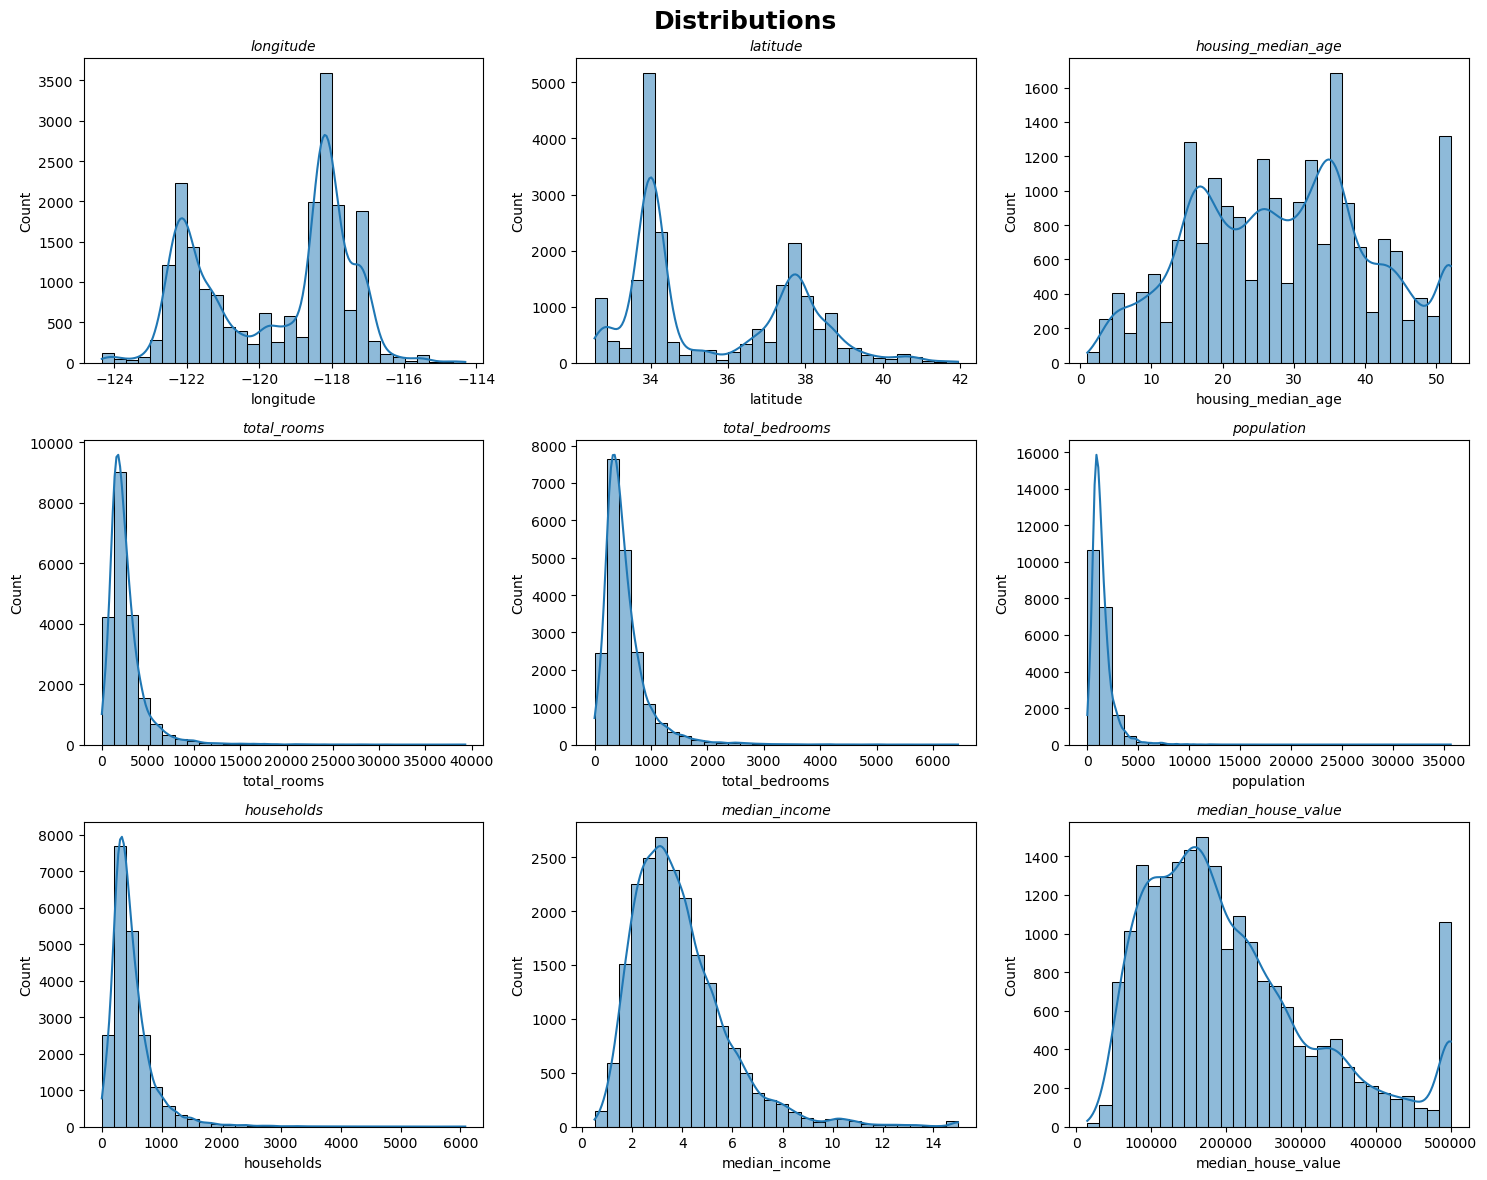

In [8]:
columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value']

fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize=(15,12))
fig.suptitle("Distributions", fontsize = 18, fontweight = "bold")

for i, col in enumerate(columns):
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx]
    sns.histplot(data = df, x = col, kde=True, ax=ax, bins=30)
    ax.set_title(col, fontsize=10, fontstyle = "italic")

plt.tight_layout()
plt.show()
     

    
   

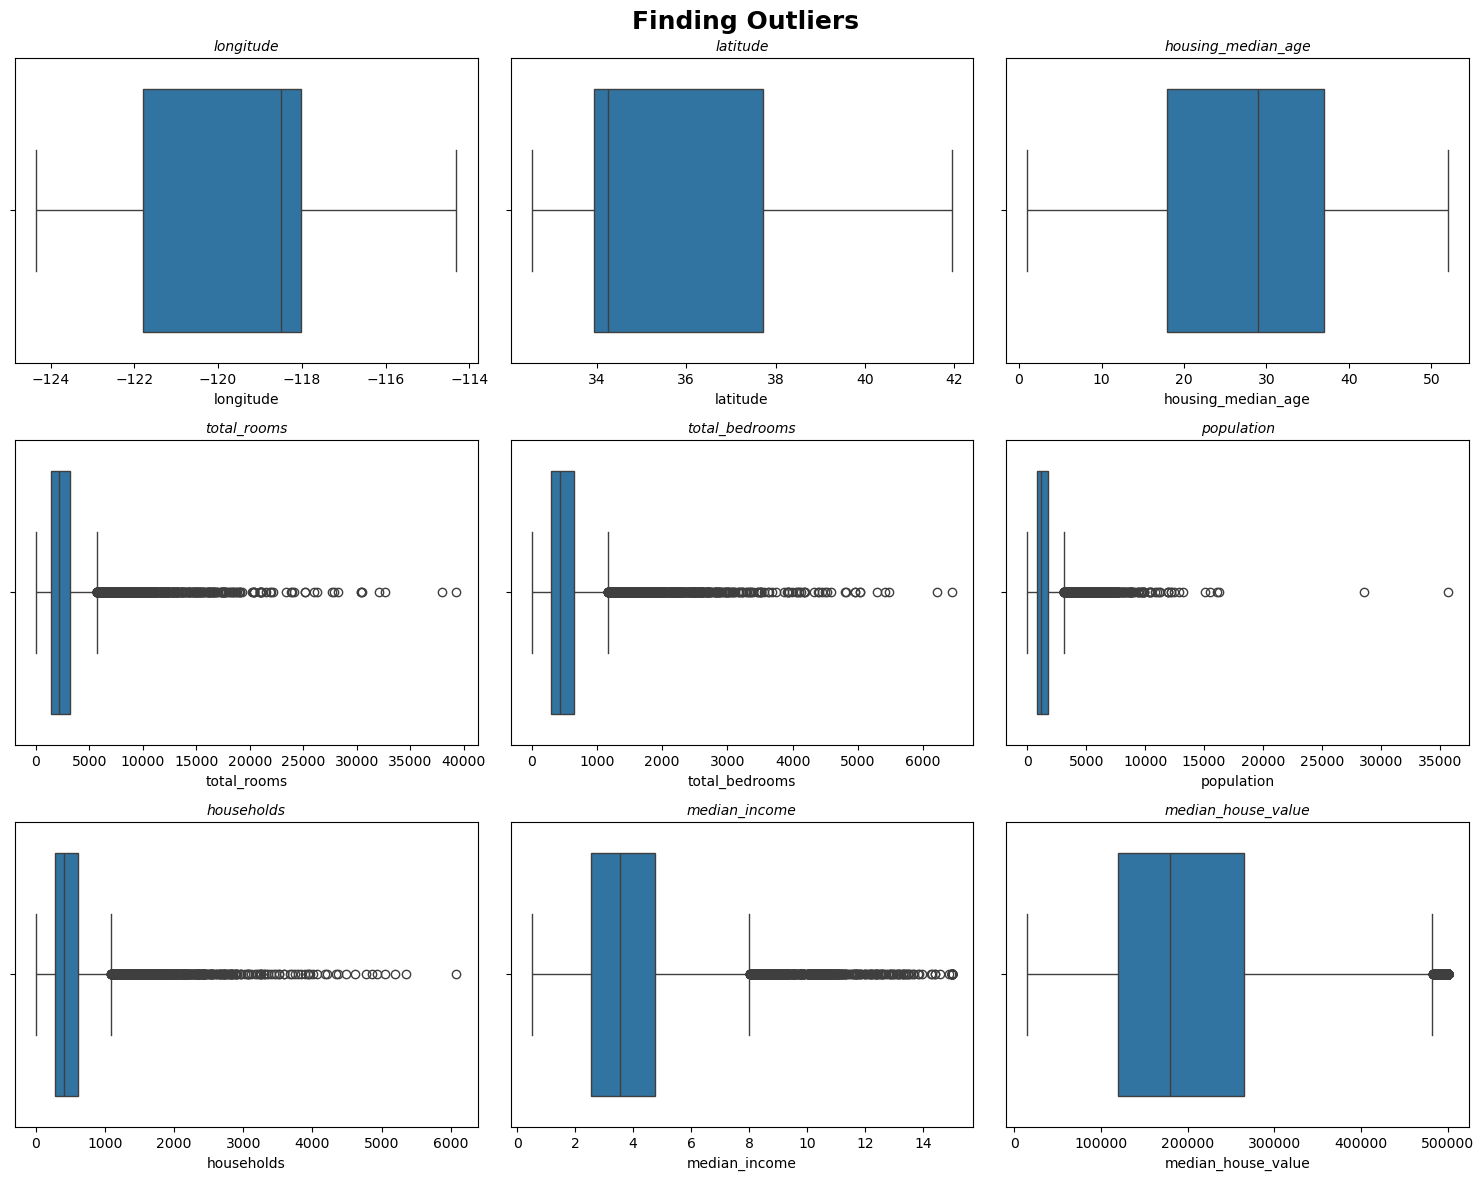

In [9]:
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize=(15,12))
fig.suptitle("Finding Outliers", fontsize = 18, fontweight = "bold")

for i, col in enumerate(columns):
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx]
    sns.boxplot(data = df, x = col, ax=ax)
    ax.set_title(col, fontsize=10, fontstyle = "italic")

plt.tight_layout()
plt.show()
     

In [10]:
def find_outliers_iqr(df, threshold = 1.5):
    outlier_summary = {}

    numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outliers = df[ (df[col] < lower_bound) | (df[col] > upper_bound)]
        
        outlier_summary[col] = {
            "outlier_count" : outliers.shape[0],
            "outlier_percentage" : 100 * outliers.shape[0] / df.shape[0],
            "lower_bound" : lower_bound,
            "upper_bound" : upper_bound
        }
    return pd.DataFrame(outlier_summary)

In [11]:
find_outliers_iqr(df)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
outlier_count,0.000,0.00,0.0,1287.000000,1271.000000,1196.000000,1220.000000,681.000000,1071.000000
outlier_percentage,0.000,0.00,0.0,6.235465,6.157946,5.794574,5.910853,3.299419,5.188953
lower_bound,-127.485,28.26,-10.5,-1102.625000,-230.500000,-620.000000,-207.500000,-0.706375,-98087.500000
upper_bound,-112.325,43.38,65.5,5698.375000,1173.500000,3132.000000,1092.500000,8.013025,482412.500000


In [12]:
def remove_outliers_from_column(df,target_col, threshold = 1.5):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    return df[ (df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [13]:
df_target_clean=remove_outliers_from_column(df,'median_house_value')

In [14]:
X=df_target_clean.drop('median_house_value',axis=1)
y=df_target_clean['median_house_value']

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=15)

In [17]:
X_train['total_bedrooms']=X_train['total_bedrooms'].fillna(X_train['total_bedrooms'].median())

In [18]:
X_test['total_bedrooms']=X_test['total_bedrooms'].fillna(X_train['total_bedrooms'].median())

In [19]:
X_train.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64

In [20]:
X_test.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64

In [21]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [27]:
one_hot=['ocean_proximity']

In [28]:
transform=ColumnTransformer(
    [
        ('one',OneHotEncoder(drop='first',handle_unknown='ignore'),one_hot)
    ],remainder='passthrough'
)

In [29]:
X_train=transform.fit_transform(X_train)
X_test=transform.transform(X_test)

In [33]:
encoded_cols=transform.get_feature_names_out()

In [35]:
X_train=pd.DataFrame(X_train,columns=encoded_cols)
X_test=pd.DataFrame(X_test,columns=encoded_cols)

In [36]:
X_train

,one__ocean_proximity_INLAND,one__ocean_proximity_ISLAND,one__ocean_proximity_NEAR BAY,one__ocean_proximity_NEAR OCEAN,remainder__longitude,remainder__latitude,remainder__housing_median_age,remainder__total_rooms,remainder__total_bedrooms,remainder__population,remainder__households,remainder__median_income
0,1.0,0.0,0.0,0.0,-118.00,34.10,34.0,2249.0,460.0,1544.0,441.0,3.4005
1,0.0,0.0,0.0,0.0,-116.95,33.31,16.0,2921.0,639.0,1838.0,540.0,2.2393
2,1.0,0.0,0.0,0.0,-117.34,34.02,28.0,2683.0,708.0,2047.0,636.0,2.2750
3,0.0,0.0,0.0,0.0,-117.92,33.64,24.0,2539.0,695.0,1623.0,611.0,3.0708
4,1.0,0.0,0.0,0.0,-122.66,39.03,27.0,1446.0,329.0,594.0,255.0,1.1650
...,...,...,...,...,...,...,...,...,...,...,...,...
13693,0.0,0.0,0.0,0.0,-118.16,34.06,27.0,1675.0,274.0,785.0,275.0,5.8280
13694,0.0,0.0,1.0,0.0,-122.16,37.48,36.0,2238.0,479.0,1949.0,457.0,2.3769
13695,1.0,0.0,0.0,0.0,-115.54,32.79,30.0,752.0,194.0,733.0,186.0,1.6607
13696,0.0,0.0,0.0,0.0,-118.35,33.93,31.0,2746.0,697.0,1973.0,598.0,3.5139


In [39]:
from sklearn.preprocessing import PowerTransformer

In [40]:
pt_x=PowerTransformer(method='yeo-johnson')

In [42]:
X_train_transformed = pt_x.fit_transform(X_train)
X_test_transformed = pt_x.transform(X_test)

In [43]:
X_train_transformed_df=pd.DataFrame(X_train_transformed,columns=encoded_cols)

In [45]:
X_train_transformed_df

,one__ocean_proximity_INLAND,one__ocean_proximity_ISLAND,one__ocean_proximity_NEAR BAY,one__ocean_proximity_NEAR OCEAN,remainder__longitude,remainder__latitude,remainder__housing_median_age,remainder__total_rooms,remainder__total_bedrooms,remainder__population,remainder__households,remainder__median_income
0,1.411199,-0.014801,-0.340747,-0.375912,2.528533e-14,-0.670999,0.486589,0.050535,0.024355,0.358262,0.058133,-0.018646
1,-0.708617,-0.014801,-0.340747,-0.375912,2.636780e-14,-1.204054,-0.970340,0.432472,0.522760,0.628352,0.363502,-0.940026
2,1.411199,-0.014801,-0.340747,-0.375912,2.595146e-14,-0.721608,0.022996,0.305957,0.685565,0.800713,0.621156,-0.907275
3,-0.708617,-0.014801,-0.340747,-0.375912,2.536860e-14,-0.972136,-0.296774,0.225063,0.655876,0.434484,0.557085,-0.254036
4,1.411199,-0.014801,-0.340747,-0.375912,2.126077e-14,1.423110,-0.056065,-0.548070,-0.448978,-0.944478,-0.697868,-2.133232
...,...,...,...,...,...,...,...,...,...,...,...,...
13693,-0.708617,-0.014801,-0.340747,-0.375912,2.511880e-14,-0.696213,-0.056065,-0.355082,-0.693283,-0.593331,-0.599422,1.324302
13694,-0.708617,-0.014801,2.934729,-0.375912,2.162159e-14,0.937396,0.637451,0.043574,0.083852,0.721670,0.110812,-0.815634
13695,1.411199,-0.014801,-0.340747,-0.375912,2.792211e-14,-1.599025,0.179499,-1.336357,-1.128929,-0.681751,-1.090558,-1.525335
13696,-0.708617,-0.014801,-0.340747,-0.375912,2.492451e-14,-0.779412,0.256983,0.340278,0.660471,0.741306,0.522974,0.058431


In [46]:
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

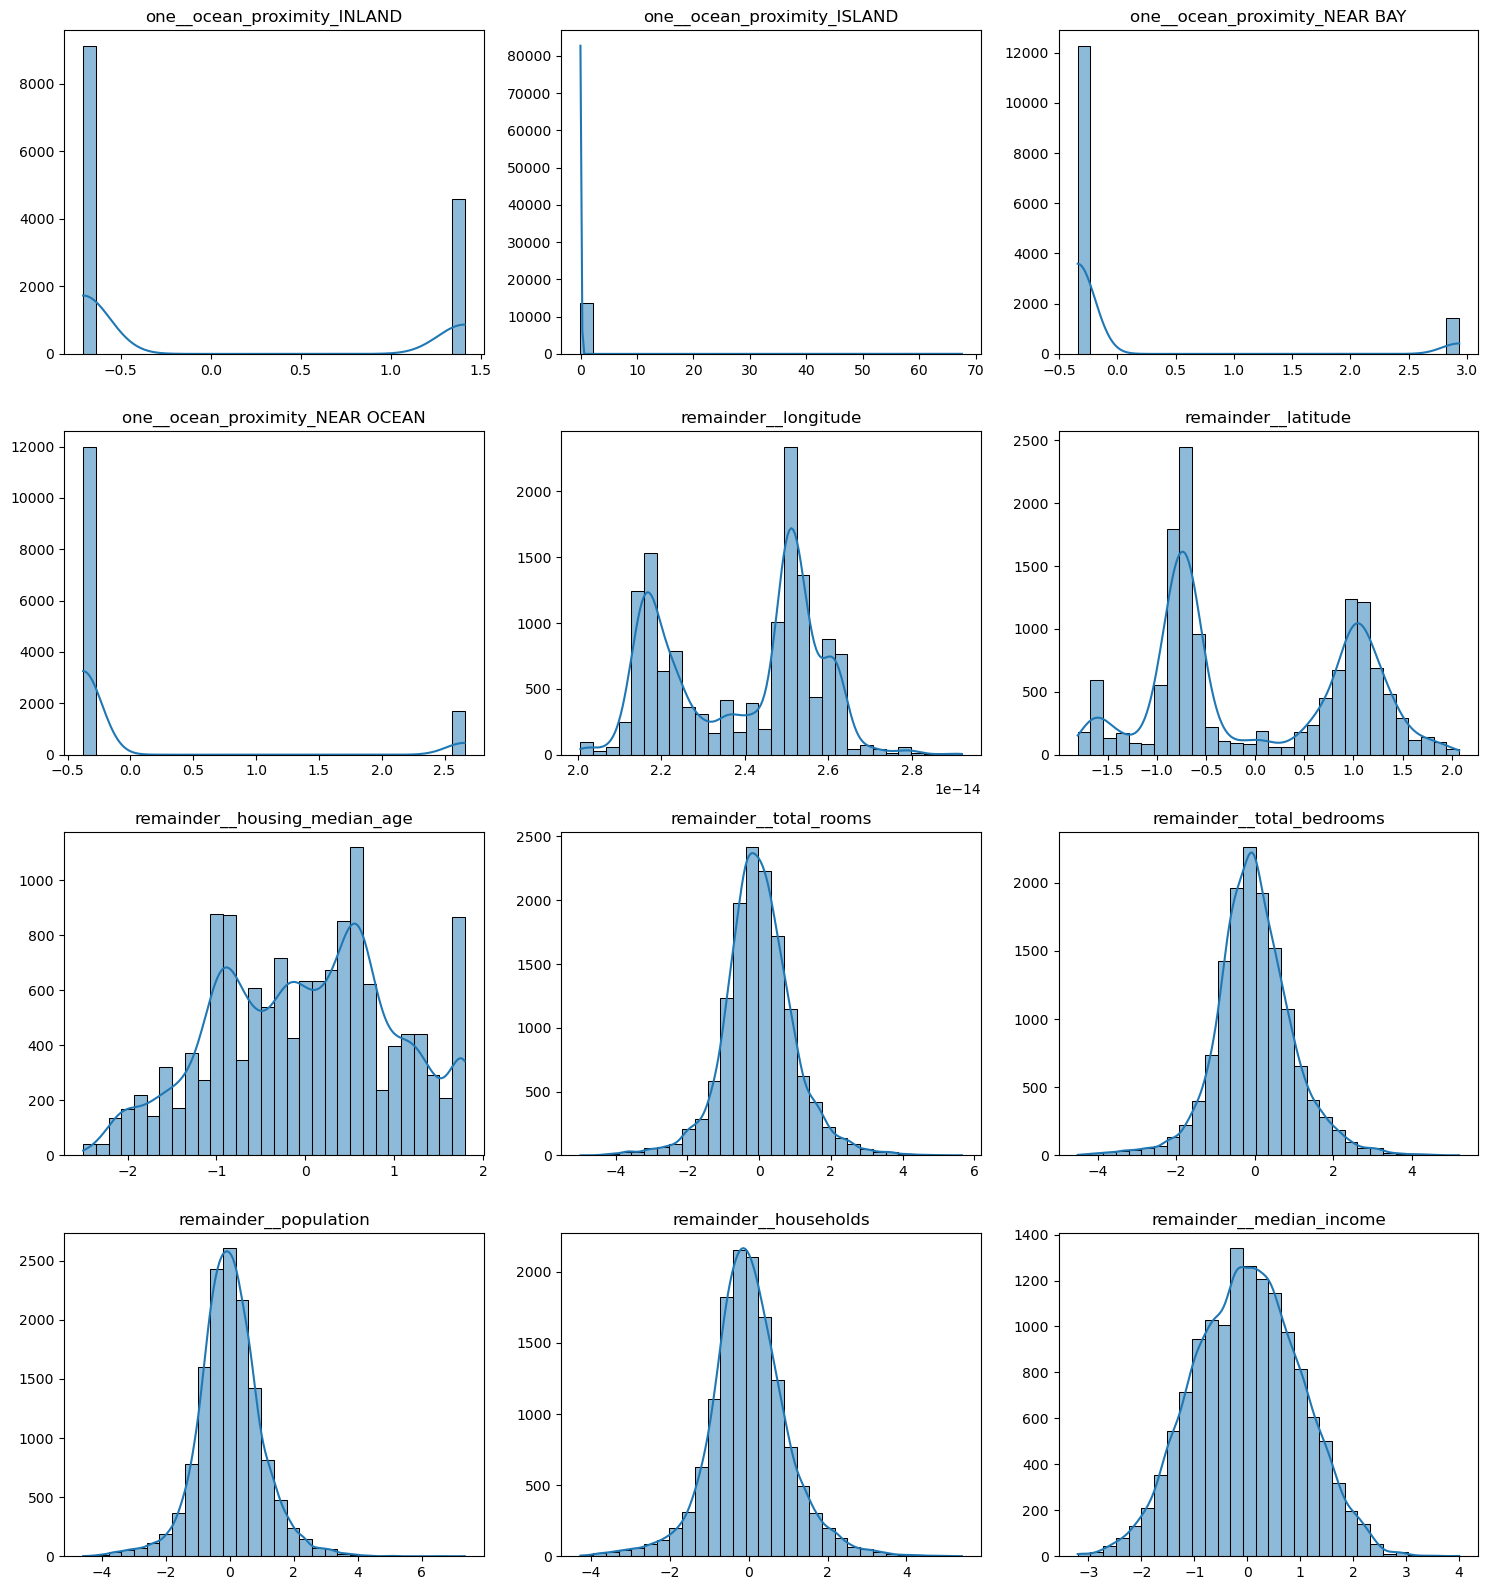

In [47]:
plot_all_histograms(X_train_transformed_df)

In [48]:
from scipy.stats import boxcox

In [49]:
y_train_transformed, lambda_y = boxcox(y_train)

In [50]:
from lightgbm import LGBMRegressor

In [51]:
model = LGBMRegressor()
model.fit(X_train_transformed, y_train_transformed)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000520 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1830
[LightGBM] [Info] Number of data points in the train set: 13698, number of used features: 11
[LightGBM] [Info] Start training from score 79.710806


LGBMRegressor()

In [52]:
y_pred_transformed = model.predict(X_test_transformed)

# (inverse Box-Cox)
def inverse_boxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1 / lambda_)

# original scaling of predictions
y_pred_original = inverse_boxcox(y_pred_transformed, lambda_y)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [53]:
from sklearn.metrics import mean_squared_error, r2_score
print("R2 Score:", r2_score(y_test, y_pred_original))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_original)))

R2 Score: 0.8002774120405962
RMSE: 42965.67095785482


In [54]:
#hyperparameter tuning

In [55]:
param_grid = {
    "num_leaves" : [31, 50, 70],
    "max_depth" : [-1, 5, 10],
    "learning_rate" : [0.01, 0.05, 0.1],
    "n_estimators" : [100, 300, 1000],
    "min_child_samples" : [10,20,30],
    "subsample" : [0.6, 0.8, 1.0],
    "colsample_bytree" : [0.6, 0.8, 1.0],
    "reg_alpha" : [0, 0.5, 1.0],
    "reg_lambda" : [0, 0.5, 1.0]
}

In [56]:
from sklearn.model_selection import RandomizedSearchCV

In [57]:
import warnings
warnings.filterwarnings("ignore")

In [60]:
random_search = RandomizedSearchCV(
    estimator=LGBMRegressor(verbosity=-1),
    param_distributions=param_grid,
    cv=5,
    verbose=0,
    random_state=15,
    scoring="r2",
    n_jobs = -1
)

In [61]:
random_search.fit(X_train_transformed, y_train_transformed)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-

RandomizedSearchCV(cv=5, estimator=LGBMRegressor(verbosity=-1), n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [-1, 5, 10],
                                        'min_child_samples': [10, 20, 30],
                                        'n_estimators': [100, 300, 1000],
                                        'num_leaves': [31, 50, 70],
                                        'reg_alpha': [0, 0.5, 1.0],
                                        'reg_lambda': [0, 0.5, 1.0],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=15, scoring='r2')

In [65]:
random_search.best_score_

np.float64(0.8331624048521824)